# Actividad 11: CNN para imágenes relacionadas con anemia

En este Colab uso imágenes de la **conjuntiva del ojo** etiquetadas como anemia o no anemia. El conjunto no pertenece a MedMNIST: elegí uno que sí trata sobre anemia, porque BloodMNIST clasifica tipos de células y no la presencia de anemia. Fuente: [Eyes-defy-anemia, copia en Hugging Face](https://huggingface.co/datasets/Yahaira/anemia-eyes), que cita [IEEE DataPort](https://doi.org/10.21227/t5s2-4j73). Es un conjunto pequeño, por lo que los resultados sirven para practicar la metodología y no para hacer diagnósticos.

Realizo: cambio de dataset, CNN con BatchNorm y Dropout, dos tasas de aprendizaje con scheduler, comparación del aumento de datos, curvas de entrenamiento y validación, calibración y ROC.


In [1]:
# Instalo las bibliotecas que necesito al ejecutar el notebook en Google Colab.
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub", "scikit-learn", "scipy"])


0

## 1. Descargo y reviso el dataset

Uso las divisiones de entrenamiento, validación y prueba que vienen en la copia pública. Leo la clase de cada imagen a partir de su carpeta y compruebo que existan ambas etiquetas. Mantengo el color porque puede aportar información sobre la palidez de la conjuntiva.


In [2]:
import os, random, zipfile
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
from PIL import Image
from huggingface_hub import hf_hub_download
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, log_loss, confusion_matrix, classification_report
from scipy.optimize import minimize_scalar

# Uso una semilla para comparar mis experimentos con las mismas condiciones.
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

# Los archivos ZIP provienen de la copia pública de Eyes-defy-anemia.
repo = "Yahaira/anemia-eyes"
base = Path("anemia_eyes")
base.mkdir(exist_ok=True)
for split in ("train", "validation", "test"):
    folder = base / split
    if not folder.exists():
        archive = hf_hub_download(repo_id=repo, repo_type="dataset", filename=f"data/{split}.zip")
        folder.mkdir()
        with zipfile.ZipFile(archive) as z:
            # Evito rutas que intenten escribirse fuera de la carpeta de trabajo.
            for member in z.infolist():
                target = (folder / member.filename).resolve()
                if not target.is_relative_to(folder.resolve()):
                    raise ValueError("Ruta inesperada dentro del ZIP")
            z.extractall(folder)

# Las etiquetas se leen del nombre de la carpeta superior de cada JPG.
def collect(split):
    paths = sorted((base / split).rglob("*.jpg"))
    paths += sorted((base / split).rglob("*.jpeg"))
    paths += sorted((base / split).rglob("*.png"))
    if not paths:
        raise ValueError(f"No encontré imágenes en {split}; revisa la estructura descargada")
    return [(p, p.parent.name.lower().replace("_", "").replace("-", "")) for p in paths]

samples = {split: collect(split) for split in ("train", "validation", "test")}
found = {label for split in samples for _, label in samples[split]}
assert found == {"anemia", "noanemia"}, f"Etiquetas inesperadas: {found}"
class_names = ["NoAnemia", "Anemia"]  # 1 = anemia para interpretar ROC y sensibilidad.
label_to_id = {"noanemia": 0, "anemia": 1}
for split, rows in samples.items():
    counts = Counter(label for _, label in rows)
    assert len(counts) == 2, f"La partición {split} necesita ambas clases: {counts}"
    print(split, len(rows), counts)


Dispositivo: cuda


data/train.zip: reconstructing file:   0%|          |  0.00B /  421MB            

data/train.zip: downloading bytes:           |  0.00B            

data/validation.zip: reconstructing file:   0%|          |  0.00B / 51.2MB            

data/validation.zip: downloading bytes:           |  0.00B            

data/test.zip: reconstructing file:   0%|          |  0.00B / 53.7MB            

data/test.zip: downloading bytes:           |  0.00B            

train 175 Counter({'noanemia': 102, 'anemia': 73})
validation 21 Counter({'noanemia': 12, 'anemia': 9})
test 22 Counter({'noanemia': 13, 'anemia': 9})


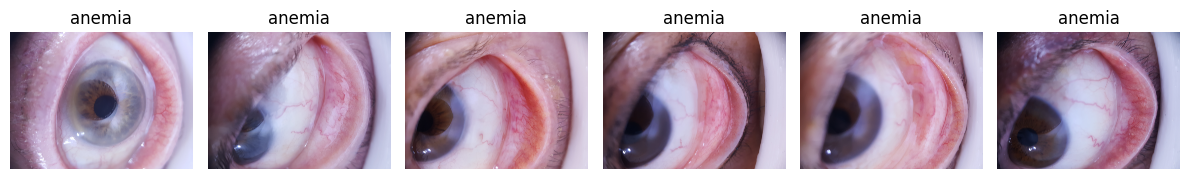

In [3]:
# Miro algunos ejemplos antes de entrenar.
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for ax, (path, label) in zip(axes, samples["train"][:6]):
    ax.imshow(Image.open(path).convert("RGB"))
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout(); plt.show()


## 2. Preparo imágenes y modelo

Redimensiono todas las imágenes a 128 × 128. La CNN usa tres canales RGB y tiene dos salidas. Agregué filtros, **BatchNorm** y **Dropout**. Solo el entrenamiento puede recibir aumentos de datos.


In [4]:
SIZE = 128
normal_transform = T.Compose([T.Resize((SIZE, SIZE)), T.ToTensor()])
aug_transform = T.Compose([
    T.Resize((SIZE, SIZE)),
    T.RandomRotation(8),
    T.RandomAffine(degrees=0, translate=(0.04, 0.04)),
    T.ToTensor(),
])

class EyeDataset(Dataset):
    def __init__(self, rows, transform):
        self.rows, self.transform = rows, transform
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, index):
        path, label = self.rows[index]
        image = Image.open(path).convert("RGB")
        return self.transform(image), label_to_id[label]

def make_loader(split, transform, shuffle=False):
    return DataLoader(EyeDataset(samples[split], transform), batch_size=16, shuffle=shuffle, num_workers=0)
train_loader = make_loader("train", normal_transform, True)
train_eval_loader = make_loader("train", normal_transform)
aug_loader = make_loader("train", aug_transform, True)
val_loader = make_loader("validation", normal_transform)
test_loader = make_loader("test", normal_transform)

class AnemiaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Extraigo características de color y forma con tres bloques convolucionales.
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1))
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(64, 2))
    def forward(self, x):
        return self.head(self.features(x))


## 3. Comparo learning rate y scheduler

Entreno tres versiones durante las mismas épocas: una tasa de `1e-3`, otra de `3e-4` con scheduler y otra con aumento de datos. Uso validación para elegir el modelo. También guardo pérdida y exactitud de ambos conjuntos para dibujar sus curvas.


In [5]:
@torch.no_grad()
def predict(model, loader, temperature=1.0):
    model.eval()
    ys, logits = [], []
    for x, y in loader:
        ys.append(y.numpy())
        logits.append(model(x.to(device)).cpu().numpy())
    y = np.concatenate(ys)
    z = np.concatenate(logits)
    prob = torch.softmax(torch.tensor(z / temperature), dim=1).numpy()
    return y, z, prob

def train_model(loader, lr, epochs=6, scheduler=False):
    torch.manual_seed(SEED)
    model = AnemiaCNN().to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    schedule = torch.optim.lr_scheduler.StepLR(optim, step_size=3, gamma=0.5) if scheduler else None
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_auc": [], "val_auc": []}
    for epoch in range(epochs):
        model.train()
        total, count = 0., 0
        for x, y in loader:
            x, y = x.to(device), y.long().to(device)
            optim.zero_grad()
            loss = nn.functional.cross_entropy(model(x), y)
            loss.backward()
            optim.step()
            total += loss.item() * len(y)
            count += len(y)
        if schedule: schedule.step()
        # Evalúo el train sin aumentos aleatorios para que la curva sea comparable.
        yt, _, pt = predict(model, train_eval_loader)
        yv, _, pv = predict(model, val_loader)
        history["train_loss"].append(total / count)
        history["val_loss"].append(log_loss(yv, pv, labels=[0, 1]))
        history["train_acc"].append(accuracy_score(yt, pt.argmax(1)))
        history["val_acc"].append(accuracy_score(yv, pv.argmax(1)))
        history["train_auc"].append(roc_auc_score(yt, pt[:, 1])) # Added this line
        history["val_auc"].append(roc_auc_score(yv, pv[:, 1]))
        print(f"Época {epoch+1}: train_loss={history['train_loss'][-1]:.3f}, val_loss={history['val_loss'][-1]:.3f}, val_acc={history['val_acc'][-1]:.3f}, val_AUC={history['val_auc'][-1]:.3f}")
    return model, history

# Primero pruebo dos configuraciones sin aumento.
model_lr1, hist_lr1 = train_model(train_loader, lr=1e-3)
model_lr2, hist_lr2 = train_model(train_loader, lr=3e-4, scheduler=True)
# Después pruebo cambios suaves en las imágenes de entrenamiento.
model_aug, hist_aug = train_model(aug_loader, lr=1e-3)

Época 1: train_loss=0.552, val_loss=0.758, val_acc=0.429, val_AUC=0.880
Época 2: train_loss=0.494, val_loss=0.905, val_acc=0.429, val_AUC=0.981
Época 3: train_loss=0.459, val_loss=0.905, val_acc=0.429, val_AUC=0.981
Época 4: train_loss=0.481, val_loss=0.668, val_acc=0.429, val_AUC=1.000
Época 5: train_loss=0.444, val_loss=0.312, val_acc=0.952, val_AUC=1.000
Época 6: train_loss=0.457, val_loss=0.252, val_acc=0.952, val_AUC=1.000
Época 1: train_loss=0.597, val_loss=0.704, val_acc=0.429, val_AUC=0.880
Época 2: train_loss=0.543, val_loss=0.777, val_acc=0.429, val_AUC=0.981
Época 3: train_loss=0.497, val_loss=0.817, val_acc=0.429, val_AUC=0.991
Época 4: train_loss=0.502, val_loss=0.647, val_acc=0.429, val_AUC=0.991
Época 5: train_loss=0.476, val_loss=0.433, val_acc=0.905, val_AUC=1.000
Época 6: train_loss=0.485, val_loss=0.317, val_acc=0.952, val_AUC=1.000
Época 1: train_loss=0.552, val_loss=0.740, val_acc=0.429, val_AUC=0.870
Época 2: train_loss=0.492, val_loss=0.883, val_acc=0.429, val_AU

## 4. Curvas de entrenamiento y validación

Comparo la pérdida y la exactitud por época. Si entrenamiento mejora y validación empeora, lo interpreto como una señal de posible sobreajuste. Las curvas me ayudan a comentar el resultado sin basarme solo en una cifra final.


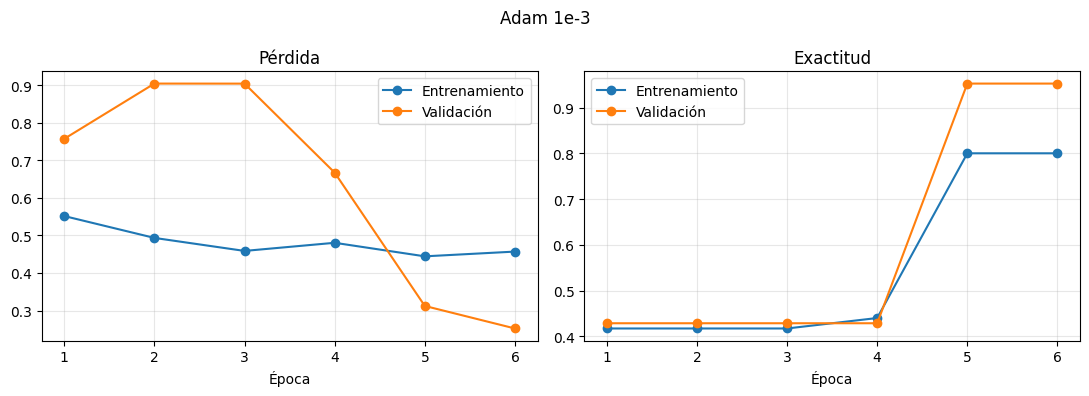

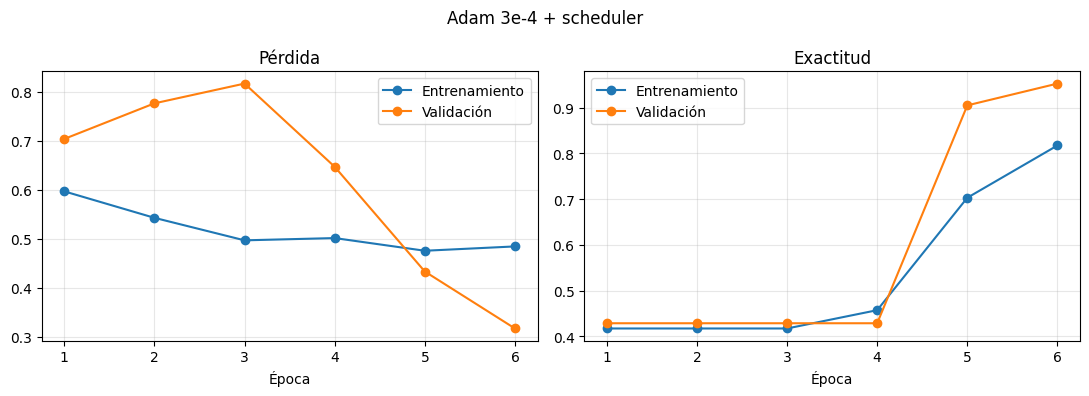

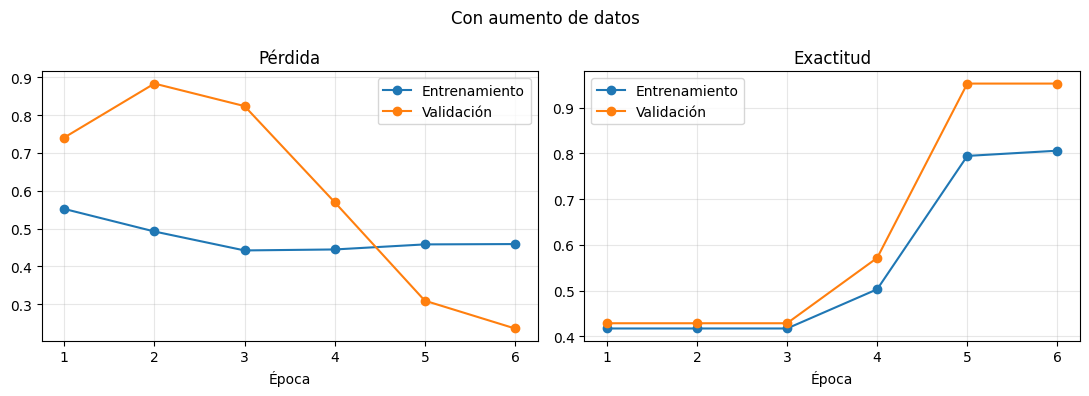

Adam 1e-3: val_acc=0.952, val_AUC=1.000
Scheduler: val_acc=0.952, val_AUC=1.000
Aumento: val_acc=0.952, val_AUC=0.991


In [6]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for i, metric in enumerate(("loss", "acc")):
        ax[i].plot(epochs, history[f"train_{metric}"], marker="o", label="Entrenamiento")
        ax[i].plot(epochs, history[f"val_{metric}"], marker="o", label="Validación")
        ax[i].set_title("Pérdida" if metric == "loss" else "Exactitud")
        ax[i].set_xlabel("Época")
        ax[i].legend()
        ax[i].grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

plot_history(hist_lr1, "Adam 1e-3")
plot_history(hist_lr2, "Adam 3e-4 + scheduler")
plot_history(hist_aug, "Con aumento de datos")

for name, hist in [("Adam 1e-3", hist_lr1), ("Scheduler", hist_lr2), ("Aumento", hist_aug)]:
    print(f"{name}: val_acc={hist['val_acc'][-1]:.3f}, val_AUC={hist['val_auc'][-1]:.3f}")


## 5. Calibración y curva ROC

Selecciono con AUC de validación, calibro con **validación** y evalúo una sola vez en **prueba**. La calibración por temperatura busca mejores probabilidades; el AUC puede quedar igual porque el orden de las predicciones no cambia. En la curva ROC, la clase positiva (`1`) significa **anemia**.


Modelo elegido: Adam 1e-3; temperatura: 0.291
Original: exactitud=0.818, AUC=0.846, log_loss=0.449
Calibrado: exactitud=0.818, AUC=0.846, log_loss=0.734
              precision    recall  f1-score   support

    NoAnemia       0.91      0.77      0.83        13
      Anemia       0.73      0.89      0.80         9

    accuracy                           0.82        22
   macro avg       0.82      0.83      0.82        22
weighted avg       0.83      0.82      0.82        22

Matriz de confusión (filas=reales, columnas=predicción):
[[10  3]
 [ 1  8]]


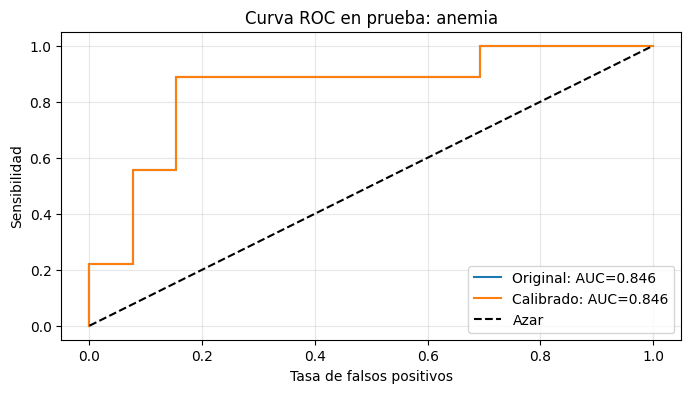

In [9]:
candidates = [("Adam 1e-3", model_lr1, hist_lr1),
              ("Adam 3e-4 + scheduler", model_lr2, hist_lr2),
              ("Aumento", model_aug, hist_aug)]
name, best_model, _ = max(candidates, key=lambda item: item[2]["val_auc"][-1])
y_val, z_val, _ = predict(best_model, val_loader)

# Ajusto una temperatura con validación; nunca uso test para elegirla.
def loss_at_temperature(log_t):
    probabilities = torch.softmax(torch.tensor(z_val / np.exp(log_t)), dim=1).numpy()
    return log_loss(y_val, probabilities, labels=[0, 1])
result = minimize_scalar(loss_at_temperature, bounds=(np.log(0.05), np.log(20)), method="bounded")
temperature = float(np.exp(result.x))
y_test, z_test, p_raw = predict(best_model, test_loader)
p_cal = torch.softmax(torch.tensor(z_test / temperature), dim=1).numpy()
print(f"Modelo elegido: {name}; temperatura: {temperature:.3f}")
for label, prob in [("Original", p_raw), ("Calibrado", p_cal)]:
    print(f"{label}: exactitud={accuracy_score(y_test, prob.argmax(1)):.3f}, "
          f"AUC={roc_auc_score(y_test, prob[:, 1]):.3f}, "
          f"log_loss={log_loss(y_test, prob, labels=[0,1]):.3f}")
print(classification_report(y_test, p_cal.argmax(1), target_names=class_names, zero_division=0))
print("Matriz de confusión (filas=reales, columnas=predicción):")
print(confusion_matrix(y_test, p_cal.argmax(1), labels=[0, 1]))

# Comparo ROC antes y después de la calibración.
plt.figure(figsize=(8, 4))
for label, prob in [("Original", p_raw), ("Calibrado", p_cal)]:
    fpr, tpr, _ = roc_curve(y_test, prob[:, 1])
    plt.plot(fpr, tpr, label=f"{label}: AUC={auc(fpr, tpr):.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC en prueba: anemia")
plt.legend(); plt.grid(alpha=0.3); plt.show()


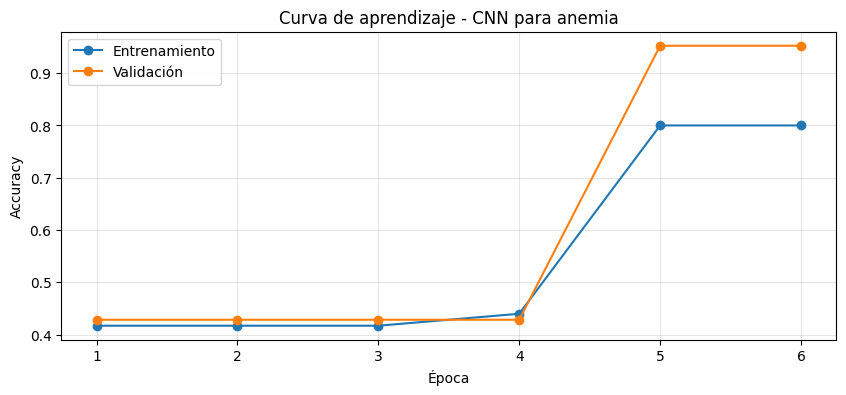

In [11]:
import numpy as np
import matplotlib.pyplot as plt

train_acc = np.array(hist_lr1["train_acc"])
val_acc = np.array(hist_lr1["val_acc"])

plt.figure(figsize=(10, 4))

plt.plot(
    np.arange(1, len(train_acc) + 1),
    train_acc,
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    np.arange(1, len(val_acc) + 1),
    val_acc,
    marker="o",
    label="Validación"
)

plt.title("Curva de aprendizaje - CNN para anemia")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

El dataset presenta una distribución de imágenes entre las clases anemia y no anemia. Se evaluó la cantidad de muestras disponibles para identificar posibles diferencias en la representación de las clases.

In [17]:
from collections import Counter
import matplotlib.pyplot as plt

# Extract labels from the training samples and convert to IDs
train_labels_ids = [label_to_id[label_str] for _, label_str in samples['train']]
conteo = Counter(train_labels_ids)

print("Distribución de clases:")
for clase, cantidad in conteo.items():
    print(class_names[clase], cantidad)

Distribución de clases:
Anemia 73
NoAnemia 102


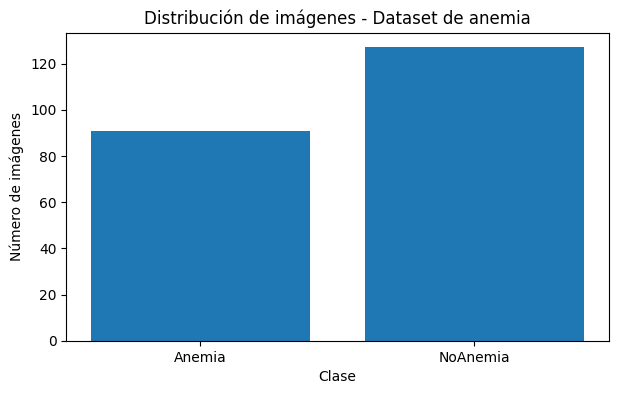

In [15]:
# Calculate the distribution of all images across all splits
all_labels_ids = []
for split in samples:
    for _, label_str in samples[split]:
        all_labels_ids.append(label_to_id[label_str]) # Map string labels to integer IDs
conteo = Counter(all_labels_ids)

plt.figure(figsize=(7, 4))

plt.bar(
    [class_names[i] for i in conteo.keys()],
    conteo.values()
)

plt.title("Distribución de imágenes - Dataset de anemia")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")

plt.show()